In [1]:
import matplotlib.pyplot as plt
import numpy as np
import json
import os
from pathlib import Path
from tqdm.notebook import tqdm

In [2]:
plt.rcParams['font.size'] = 16
plt.rcParams['axes.linewidth'] = 0.8
plt.rcParams['grid.alpha'] = 0.3

In [3]:
EVAL_RESULTS_DIR = Path("evaluation_results")

TASK_CONFIG = {
    'MCQ': {
        'primary': 'ArabicMMLU',
        'secondary': 'belebele',
        'prompt_ids': {
            'primary': [14571, 14869, 14787, 14797, 14798],
            'secondary': [14854, 14853, 14801, 14800, 14575],
        },
        'metric': 'acc_norm,none',
        'scale': 100,
    },
    'NLI': {
        'primary': 'ArEntail',
        'secondary': 'ArabicTE',
        'prompt_ids': {
            'primary': [14581, 14816, 14818, 14819, 14820],
            'secondary': [14582, 14673, 14724, 14805, 14855],
        },
        'metric': 'acc_norm,none',
        'scale': 100,
    },
    'Dialect': {
        'primary': 'AraBench_dev',
        'secondary': 'Arabic_Dialects_Dataset',
        'prompt_ids': {
            'primary': [14852, 14850, 14789, 14781, 14561],
            'secondary': [14102, 14783, 14784, 14790, 14851],
        },
        'metric': 'acc_norm,none',
        'scale': 100,
    },
    'Sarcasm': {
        'primary': 'ArSarcasm_v2',
        'secondary': 'iSarcasmEval_task_A',
        'prompt_ids': {
            'primary': [14779, 14802, 14835, 14837, 14838],
            'secondary': [14602, 14780, 14859, 14860, 14864],
        },
        'metric': 'acc_norm,none',
        'scale': 100,
    },
    'Trans.': {
        'primary': 'opus-100',
        'secondary': 'tatoeba_mt',
        'prompt_ids': {
            'primary': [14684, 14688, 14680, 14682, 14640],
            'secondary': [14866, 14867, 14868, 14889, 14890],
        },
        'metric': 'calculate_bleu,none',
        'scale': 1,
    },
    'Summ.': {
        'primary': 'xlsum',
        'secondary': 'AraSum',
        'prompt_ids': {
            'primary': [14871, 14803, 14856, 14858, 14668],
            'secondary': [14891, 14857, 14736, 14735, 14628],
        },
        'metric': 'calculate_bleu,none',
        'scale': 1,
    },
}

TASK_DIR_MAP = {
    'MCQ': 'NLU',
    'NLI': 'NLI',
    'Dialect': 'dialect_identification',
    'Sarcasm': 'sarcasm_detection',
    'Trans.': 'machine_translation',
    'Summ.': 'summarization',
}

MODEL_CONFIG = {
    'AceGPT-v2-8B': {
        'Base': 'AceGPT-v2-8B',
        'Chat': 'AceGPT-v2-8B-Chat',
        'Tuned': 'AceGPT-v2-8B-tuned',
    },
    'LLaMA3.1-8B': {
        'Base': 'Meta-Llama-3.1-8B',
        'Instruct': 'Meta-Llama-3.1-8B-Instruct',
        'Tuned': 'Meta-Llama-3.1-8B-tuned',
    },
    'Qwen3-8B': {
        'Base': 'Qwen3-8B',
        'Chat': 'Qwen3-8B-chat',
        'Tuned': 'Qwen3-8B-tuned',
    },
}


def get_prompt_ids(task_config, dataset_type):
    pids = task_config['prompt_ids']
    if isinstance(pids, dict):
        return pids[dataset_type]
    return pids


def extract_metric(result_json, metric_key):
    results = result_json.get('results', {})
    for task_name, metrics in results.items():
        if metric_key in metrics:
            val = metrics[metric_key]
            if isinstance(val, (int, float)):
                return val
    return None


def load_results():
    data = {}
    total = len(TASK_CONFIG) * len(MODEL_CONFIG) * 2 * 3
    pbar = tqdm(total=total, desc="Loading results")
    
    for task_name, task_cfg in TASK_CONFIG.items():
        task_dir = TASK_DIR_MAP[task_name]
        metric_key = task_cfg['metric']
        scale = task_cfg['scale']
        
        data[task_name] = {'intra_dataset': {}, 'intra_task': {}}
        
        for model_display, variants in MODEL_CONFIG.items():
            for condition, dataset_type in [('intra_dataset', 'primary'), ('intra_task', 'secondary')]:
                prompt_ids = get_prompt_ids(task_cfg, dataset_type)
                dataset_name = task_cfg[dataset_type]
                
                for variant_label, model_dir in variants.items():
                    pbar.set_postfix_str(f"{task_name}/{model_dir}/{variant_label}")
                    scores = []
                    for pid in prompt_ids:
                        fpath = EVAL_RESULTS_DIR / model_dir / task_dir / dataset_name / f"prompt_{pid}.json"
                        if fpath.exists():
                            with open(fpath) as f:
                                result = json.load(f)
                            val = extract_metric(result, metric_key)
                            if val is not None:
                                scores.append(val * scale)
                            else:
                                print(f"WARNING: metric '{metric_key}' not found in {fpath}")
                        else:
                            print(f"WARNING: missing {fpath}")
                    
                    if model_display not in data[task_name][condition]:
                        data[task_name][condition][model_display] = {}
                    data[task_name][condition][model_display][variant_label] = scores
                    pbar.update(1)
    
    pbar.close()
    return data


data = load_results()

# Print summary
for task, conditions in data.items():
    for cond, models in conditions.items():
        for model, variants in models.items():
            for var, scores in variants.items():
                print(f"{task:>15} | {cond:>14} | {model:>14} | {var:>10} | mean={np.mean(scores):6.2f} | n={len(scores)}")

Loading results:   0%|          | 0/108 [00:00<?, ?it/s]

            MCQ |  intra_dataset |   AceGPT-v2-8B |       Base | mean= 42.35 | n=5
            MCQ |  intra_dataset |   AceGPT-v2-8B |       Chat | mean= 46.01 | n=5
            MCQ |  intra_dataset |   AceGPT-v2-8B |      Tuned | mean= 59.45 | n=5
            MCQ |  intra_dataset |    LLaMA3.1-8B |       Base | mean= 39.95 | n=5
            MCQ |  intra_dataset |    LLaMA3.1-8B |   Instruct | mean= 44.03 | n=5
            MCQ |  intra_dataset |    LLaMA3.1-8B |      Tuned | mean= 55.37 | n=5
            MCQ |  intra_dataset |       Qwen3-8B |       Base | mean= 51.30 | n=5
            MCQ |  intra_dataset |       Qwen3-8B |       Chat | mean= 49.47 | n=5
            MCQ |  intra_dataset |       Qwen3-8B |      Tuned | mean= 66.04 | n=5
            MCQ |     intra_task |   AceGPT-v2-8B |       Base | mean= 42.02 | n=5
            MCQ |     intra_task |   AceGPT-v2-8B |       Chat | mean= 57.00 | n=5
            MCQ |     intra_task |   AceGPT-v2-8B |      Tuned | mean= 58.13 | n=5
    

In [4]:
def create_scatter_plot(figsize=(20, 10)):
    """Create T0-style scatter plot comparing intra-dataset vs intra-task performance."""
    
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=figsize, sharey=False)
    
    # Brand-aligned colors per model variant
    colors = {
        'AceGPT-v2-8B': {'Base': '#7ECDC6', 'Chat': '#2BA89E', 'Tuned': '#1A6B64'},     # Teal
        'LLaMA3.1-8B':  {'Base': '#6FA8F2', 'Instruct': '#0668E1', 'Tuned': '#044A9E'},  # Meta blue
        'Qwen3-8B':     {'Base': '#B794F6', 'Chat': '#7C3AED', 'Tuned': '#5521A6'},      # Purple
    }
    
    # Baselines per dataset — verified via scripts/verify_baselines.py
    # random = mean(1/num_choices) across all samples (handles variable choice counts)
    # first_choice = % of samples where correct answer is the first option (index 0)
    dataset_baselines = {
        'ArabicMMLU':       {'random': 29.4, 'first_choice': 31.9},  # Variable choices: 2/3/4/5
        'Belebele':         {'random': 25.0, 'first_choice': 22.9},
        'ArEntail':         {'random': 50.0, 'first_choice': 50.0},
        'ArabicTE':         {'random': 50.0, 'first_choice': 47.9},
        'AraBench':         {'random': 16.7, 'first_choice': 14.5},
        'Arabic Dialects':  {'random': 20.0, 'first_choice': 17.6},
        # Sarcasm excluded: different prompts use different answer-choice orderings
        # (e.g. ['Non sarcastic', 'sarcastic'] vs ['True', 'False']), so there is
        # no single first-choice-bias value across all prompts.
        # See scripts/verify_baselines.py for details.
        'ArSarcasm':        {'random': 50.0, 'first_choice': None},
        'iSarcasmEval':     {'random': 50.0, 'first_choice': None},
    }
    
    # Dataset name mapping for baselines
    baseline_map = {
        'intra_dataset': {'MCQ': 'ArabicMMLU', 'NLI': 'ArEntail', 'Dialect': 'AraBench', 'Sarcasm': 'ArSarcasm'},
        'intra_task':    {'MCQ': 'Belebele', 'NLI': 'ArabicTE', 'Dialect': 'Arabic Dialects', 'Sarcasm': 'iSarcasmEval'},
    }
    
    tasks = list(data.keys())
    models = list(MODEL_CONFIG.keys())
    accuracy_tasks = ['MCQ', 'NLI', 'Dialect', 'Sarcasm']
    conditions = ['intra_dataset', 'intra_task']
    condition_titles = ['Intra-Dataset', 'Intra-Task']
    
    for cond_idx, (condition, ax, title) in enumerate(zip(conditions, [ax1, ax2], condition_titles)):
        x_positions = np.arange(len(tasks))
        
        # Task separators
        for i in range(len(tasks) - 1):
            ax.axvline(x=i + 0.5, color='lightgray', linewidth=1, alpha=0.7)
        # Major divider between classification and generation
        ax.axvline(x=3.5, color='gray', linewidth=3, alpha=0.8)
        
        # Baseline markers for accuracy tasks
        for task_idx, task in enumerate(accuracy_tasks):
            x_center = x_positions[task_idx]
            x_left, x_right = x_center - 0.4, x_center + 0.4
            
            dataset_name = baseline_map[condition][task]
            baselines = dataset_baselines[dataset_name]
            
            ax.hlines(baselines['random'], x_left, x_right,
                      colors='green', linestyles='dashed', linewidth=2, alpha=0.8)
            if baselines['first_choice'] is not None:
                ax.hlines(baselines['first_choice'], x_left, x_right,
                          colors='purple', linestyles='dotted', linewidth=2, alpha=0.8)
        
        # Scatter points for each model
        n_models = len(models)
        for task_idx, task in enumerate(tasks):
            x_base = x_positions[task_idx]
            
            for model_idx, model in enumerate(models):
                model_offset = (model_idx - (n_models - 1) / 2) * 0.2
                
                for variant_key, values in data[task][condition][model].items():
                    x_pos = x_base + model_offset + np.random.normal(0, 0.03, len(values))
                    
                    ax.scatter(x_pos, values,
                               c=colors[model][variant_key],
                               alpha=0.8, s=90,
                               edgecolors='black', linewidth=0.8)
        
        # Axes styling
        ax.set_title(title, fontsize=22, fontweight='bold', pad=20)
        ax.set_xticks(x_positions)
        ax.set_xticklabels(tasks, rotation=0, ha='center', fontsize=16, fontweight='bold')
        ax.grid(True, alpha=0.3, axis='y')
        ax.set_axisbelow(True)
        ax.tick_params(axis='y', labelsize=16)
        
        # Y-axis limits
        all_values = []
        for task in tasks:
            for model in models:
                for values in data[task][condition][model].values():
                    all_values.extend(values)
        y_min, y_max = min(all_values), max(all_values)
        y_range = y_max - y_min
        ax.set_ylim(y_min - 0.05 * y_range, y_max + 0.1 * y_range)
        
        # Category labels
        y_top = ax.get_ylim()[1]
        ax.text(1.5, y_top * 0.98, 'Answer-Choices-Based Tasks',
                ha='center', va='top', fontsize=15, fontweight='bold', color='gray', alpha=0.8)
        ax.text(4.5, y_top * 0.98, 'Open-Ended\nGeneration Tasks',
                ha='center', va='top', fontsize=15, fontweight='bold', color='gray', alpha=0.8)
    
    ax1.set_ylabel('Performance Score', fontsize=20, fontweight='bold')
    
    # Legend
    legend_elements = []
    model_labels = {'AceGPT-v2-8B': 'AceGPT-v2', 'LLaMA3.1-8B': 'LLaMA-3.1', 'Qwen3-8B': 'Qwen3'}
    
    for model in models:
        for variant_key in MODEL_CONFIG[model].keys():
            legend_elements.append(
                plt.Line2D([0], [0], marker='o', color='w',
                           markerfacecolor=colors[model][variant_key],
                           markersize=12, alpha=0.8,
                           markeredgecolor='black', markeredgewidth=0.5,
                           label=f'{model_labels[model]} {variant_key}'))
    
    # Baseline legend entries
    legend_elements.extend([
        plt.Line2D([0], [0], color='green', linestyle='dashed',
                   linewidth=2, alpha=0.8, label='Random Baseline'),
        plt.Line2D([0], [0], color='purple', linestyle='dotted',
                   linewidth=2, alpha=0.8, label='First Choice Bias'),
    ])
    
    fig.legend(handles=legend_elements, loc='lower center', bbox_to_anchor=(0.5, 0.01),
              ncol=4, fontsize=16, frameon=True, fancybox=True, shadow=True,
              columnspacing=1.2, handletextpad=0.5)
    
    plt.tight_layout()
    plt.subplots_adjust(top=0.90, bottom=0.26)
    
    return fig

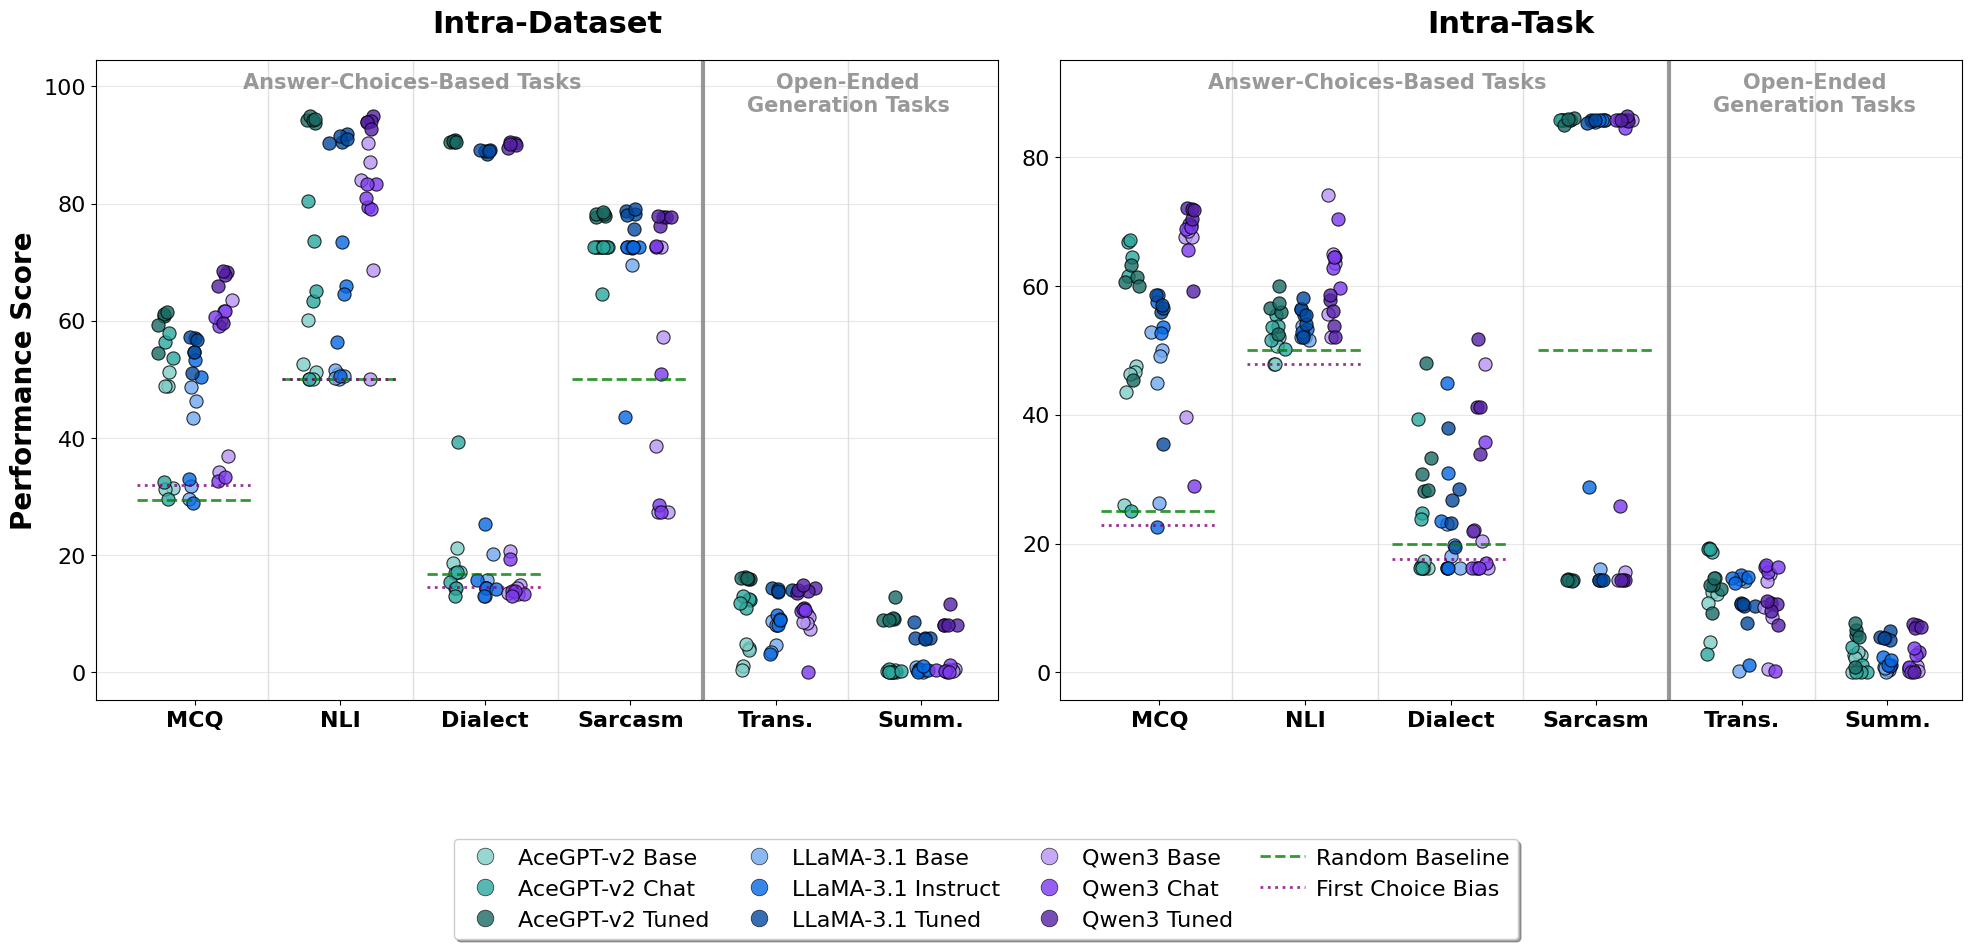

In [5]:
np.random.seed(42)  # Reproducible jitter
plot = create_scatter_plot()
plt.savefig('Notebooks/results_visualization/scatter_plot.pdf', dpi=300, bbox_inches='tight', format='pdf')
plt.show()